In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [8]:
xMacaqueBrainAreaCmp = pd.read_csv('./data_processed_all/cross_region_heatmap_matrix.csv',index_col=0)
xMacaqueBrainAreaCmp

,Spinal_cord_EX,Neocotex_EX,V1_EX,Insular_EX,ACC_EX,SNC_EX,Put_EX,CN_EX,Cerebellum_IN,CER_IN,...,Cerebellum_Microglia,Spinal_cord_Microglia,Neocotex_Microglia,V1_Microglia,Insular_Microglia,ACC_Microglia,Substantia_nigra_Microglia,SNC_Microglia,Put_Microglia,CN_Microglia
Spinal_cord_EX,1.000000,0.380199,0.524964,0.536753,0.451593,0.434516,0.286577,0.474928,0.183846,0.208236,...,-0.181406,-0.232331,-0.343571,-0.335650,-0.343123,-0.379723,-0.204860,0.021855,-0.039255,-0.302037
Neocotex_EX,0.380199,1.000000,0.632416,0.665253,0.632236,0.323205,0.466471,0.436374,0.105631,0.052419,...,-0.103491,-0.092183,-0.330856,-0.165396,-0.143138,-0.261513,-0.066248,0.010774,-0.062086,-0.212788
V1_EX,0.524964,0.632416,1.000000,0.849137,0.583940,0.458680,0.448683,0.511855,0.185617,0.201238,...,-0.198611,-0.140431,-0.355700,-0.376607,-0.284528,-0.428204,-0.143292,-0.096357,-0.173664,-0.337024
Insular_EX,0.536753,0.665253,0.849137,1.000000,0.651258,0.422148,0.454222,0.504911,0.094655,0.117099,...,-0.231665,-0.184837,-0.398761,-0.381587,-0.352899,-0.453637,-0.214046,-0.125168,-0.198515,-0.351928
ACC_EX,0.451593,0.632236,0.583940,0.651258,1.000000,0.274763,0.337688,0.671113,0.126294,0.214393,...,-0.095762,-0.147861,-0.276725,-0.280893,-0.279408,-0.524253,-0.125032,-0.043015,-0.093095,-0.400165
SNC_EX,0.434516,0.323205,0.458680,0.422148,0.274763,1.000000,0.769834,0.301952,0.290883,0.190788,...,-0.359803,-0.148665,-0.447194,-0.251606,-0.214704,-0.307880,-0.196325,-0.144696,-0.275782,-0.228609
Put_EX,0.286577,0.466471,0.448683,0.454222,0.337688,0.769834,1.000000,0.194670,0.235409,0.128126,...,-0.241797,-0.053393,-0.351234,-0.162748,-0.135879,-0.258969,-0.077714,-0.061759,-0.160773,-0.125617
CN_EX,0.474928,0.436374,0.511855,0.504911,0.671113,0.301952,0.194670,1.000000,0.146437,0.259892,...,-0.094267,-0.108492,-0.250187,-0.220033,-0.206280,-0.382308,-0.074056,0.006611,-0.091882,-0.522770
Cerebellum_IN,0.183846,0.105631,0.185617,0.094655,0.126294,0.290883,0.235409,0.146437,1.000000,0.614317,...,0.025333,-0.102290,-0.102436,-0.142013,-0.146534,-0.153166,-0.095318,-0.147220,-0.173013,-0.142603
CER_IN,0.208236,0.052419,0.201238,0.117099,0.214393,0.190788,0.128126,0.259892,0.614317,1.000000,...,-0.019251,-0.105991,-0.106934,-0.194295,-0.185439,-0.218108,-0.099711,-0.105098,-0.121446,-0.201351


<Figure size 2000x2000 with 0 Axes>

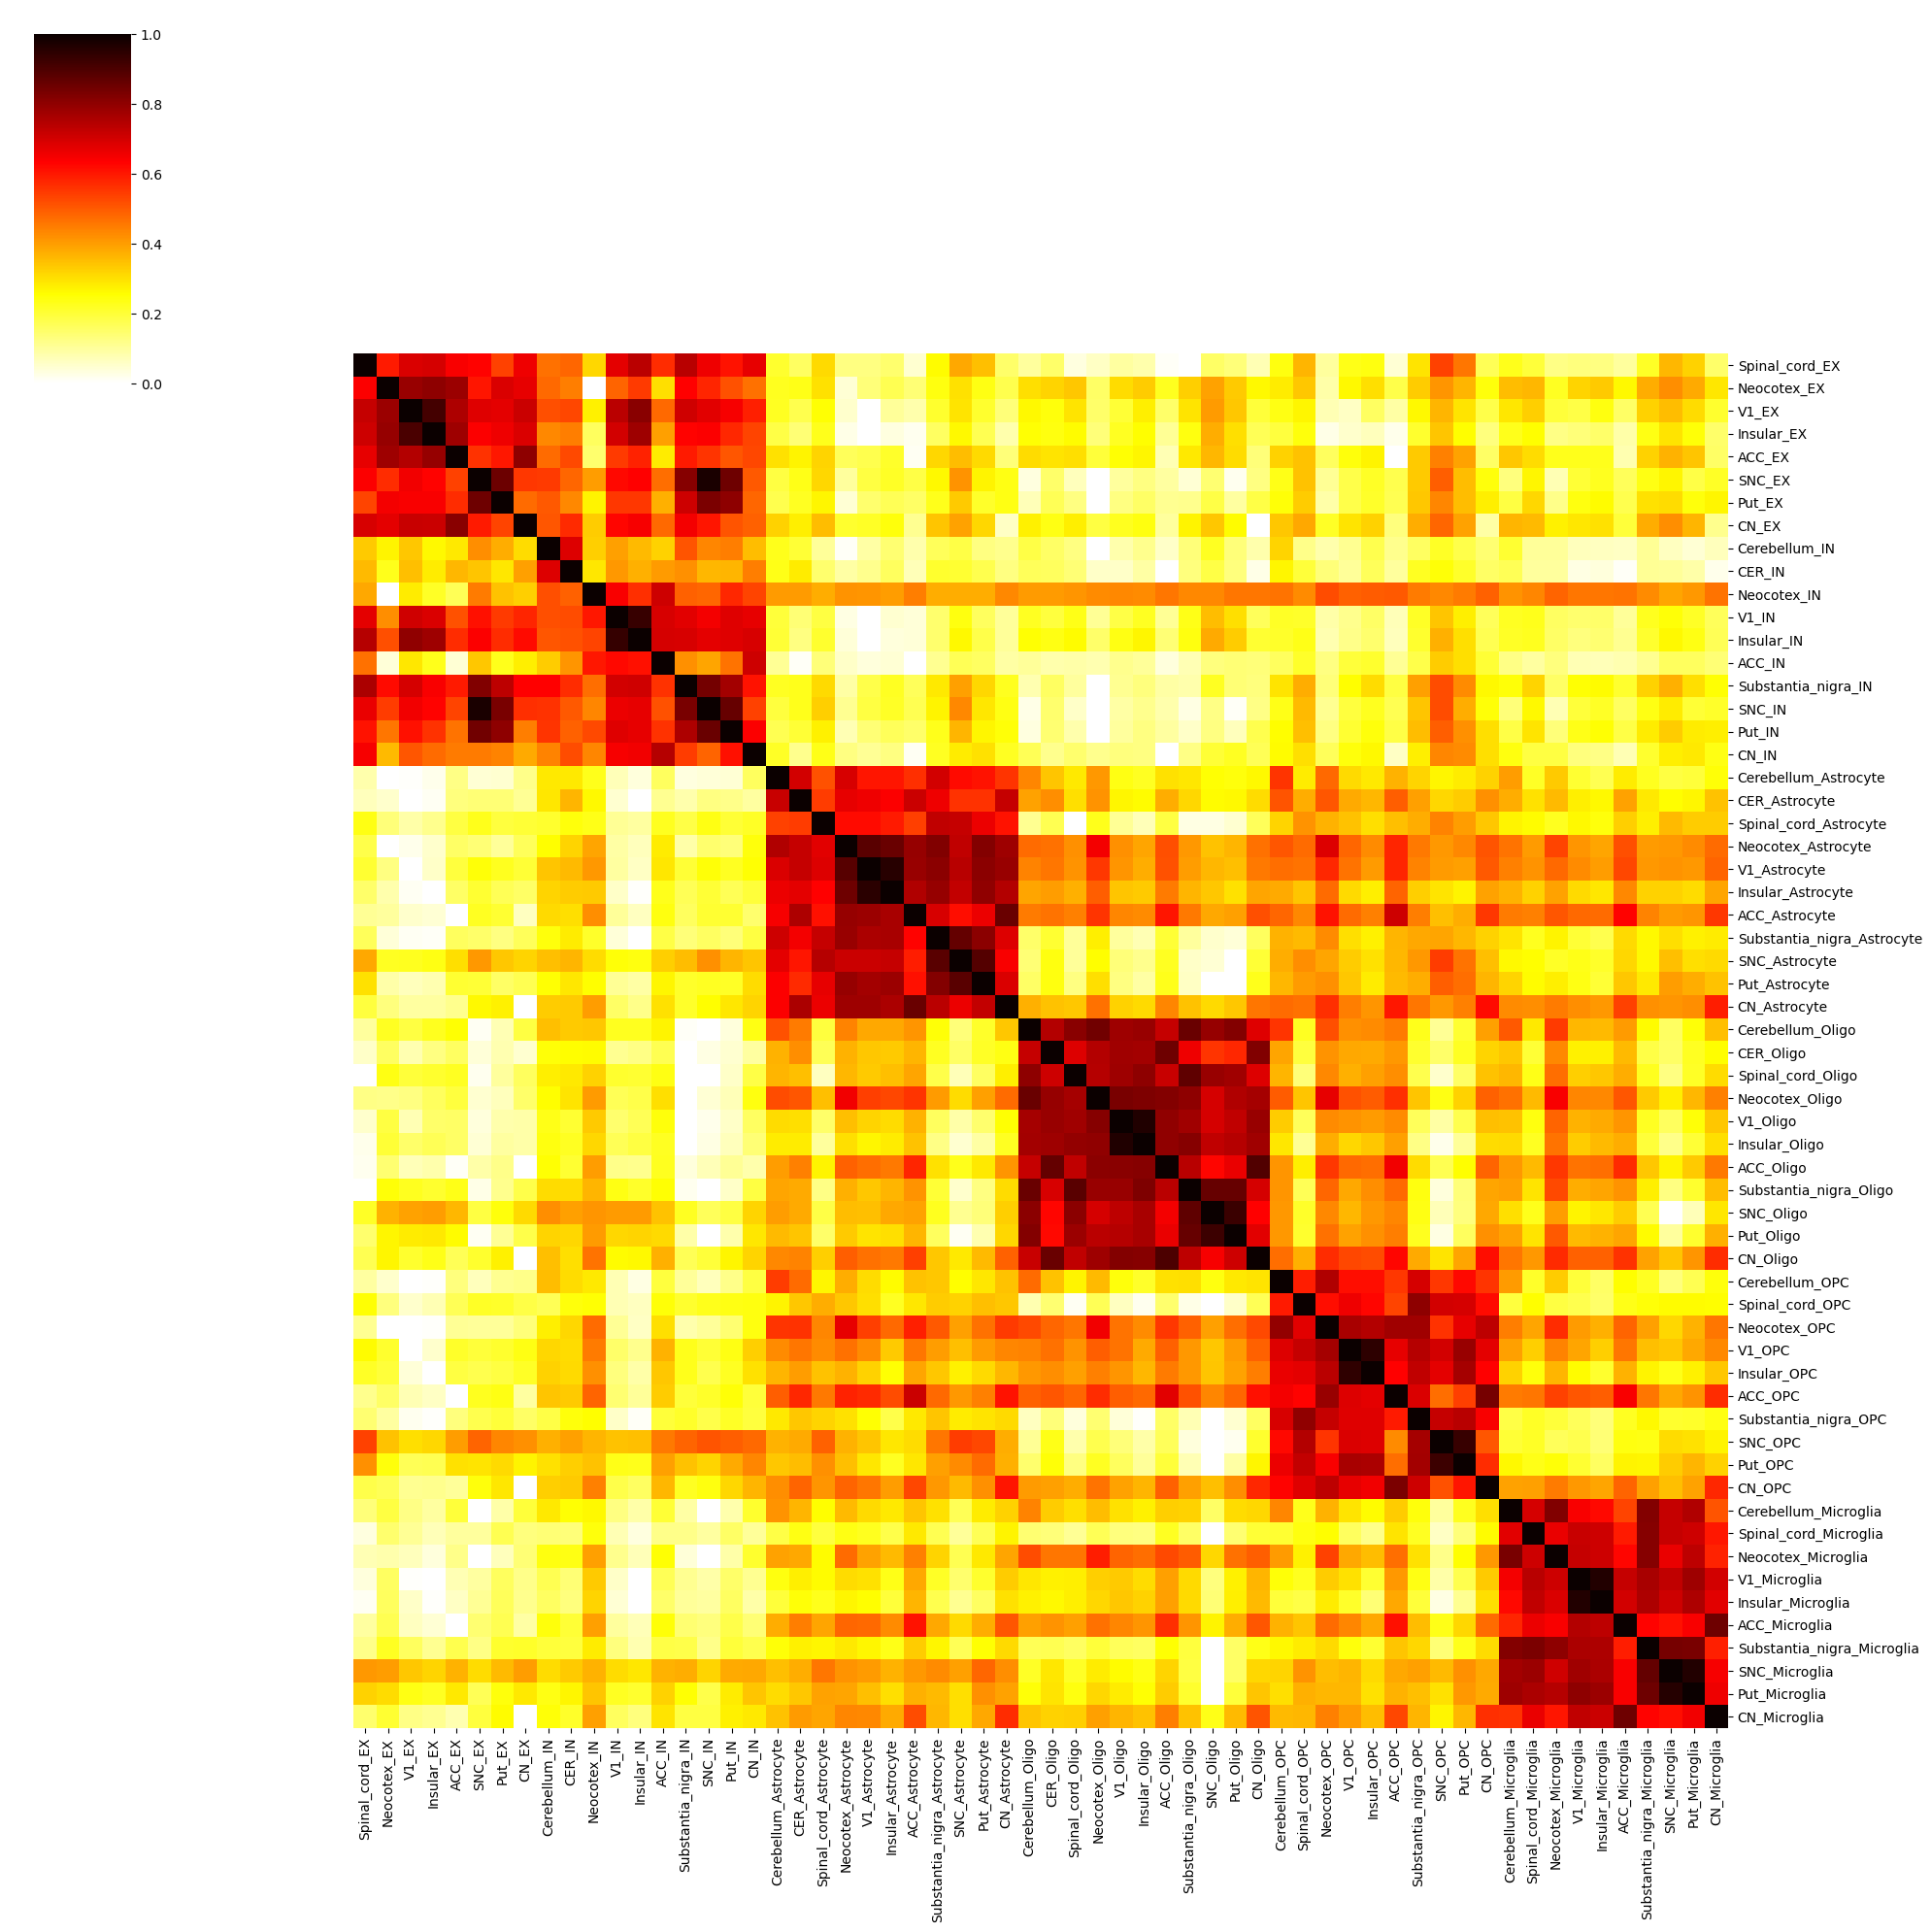

In [9]:
plt.figure(figsize=(20, 20)) 
sns.clustermap(xMacaqueBrainAreaCmp,cmap='hot_r',standard_scale=0,row_cluster=False,col_cluster=False,figsize=(20,20))
# plt.savefig('Figures/cross_region_heatmap.pdf')

In [10]:
xSpiecesGliaCmp = pd.read_csv('./data_processed_all/cross_species_heatmap_matrix.csv',index_col=0)
xSpiecesGliaCmp

,M_ins_EX,M_acc_EX,H_acc_EX,H_cor_EX,B_acc_EX,C_acc_EX,M_ins_IN,M_acc_IN,H_acc_IN,H_cor_IN,...,H_acc_OPC,H_cor_OPC,B_acc_OPC,C_acc_OPC,M_ins_Microglia,M_acc_Microglia,H_acc_Microglia,H_cor_Microglia,B_acc_Microglia,C_acc_Microglia
M_ins_EX,1.000000,0.594727,0.624229,0.436903,0.561139,0.583604,0.600918,-0.258543,0.231761,-0.185015,...,-0.422194,-0.501420,-0.460016,-0.415101,-0.334577,-0.017792,-0.336830,-0.358035,-0.367825,-0.326239
M_acc_EX,0.594727,1.000000,0.601797,0.449943,0.520645,0.584392,0.187802,-0.525393,0.031810,-0.313887,...,-0.274973,-0.299538,-0.326274,-0.319014,-0.187712,0.039977,-0.213865,-0.215449,-0.221621,-0.249764
H_acc_EX,0.624229,0.601797,1.000000,0.453842,0.580624,0.716884,0.277866,-0.352639,0.021669,-0.389420,...,-0.412771,-0.415888,-0.410698,-0.403347,-0.230326,-0.000146,-0.346440,-0.337591,-0.291689,-0.312780
H_cor_EX,0.436903,0.449943,0.453842,1.000000,0.382220,0.408831,0.054997,-0.414931,-0.075255,-0.507689,...,-0.191433,-0.326222,-0.209157,-0.204047,-0.080937,0.009980,-0.118186,-0.216921,-0.133382,-0.130189
B_acc_EX,0.561139,0.520645,0.580624,0.382220,1.000000,0.555992,0.255408,-0.248740,0.113916,-0.201478,...,-0.295696,-0.299920,-0.688396,-0.354078,-0.232156,-0.004062,-0.238349,-0.233902,-0.454309,-0.285028
C_acc_EX,0.583604,0.584392,0.716884,0.408831,0.555992,1.000000,0.262456,-0.330557,0.064488,-0.300858,...,-0.312769,-0.353969,-0.367504,-0.487024,-0.211508,0.021075,-0.257208,-0.267948,-0.282918,-0.386363
M_ins_IN,0.600918,0.187802,0.277866,0.054997,0.255408,0.262456,1.000000,0.334280,0.636705,0.404563,...,-0.414654,-0.409822,-0.400492,-0.332360,-0.336964,-0.080523,-0.354830,-0.350286,-0.334787,-0.278942
M_acc_IN,-0.258543,-0.525393,-0.352639,-0.414931,-0.248740,-0.330557,0.334280,1.000000,0.444800,0.607272,...,0.022072,0.089473,0.009501,0.095678,-0.001902,-0.070327,-0.009503,0.018758,0.010990,0.048413
H_acc_IN,0.231761,0.031810,0.021669,-0.075255,0.113916,0.064488,0.636705,0.444800,1.000000,0.611476,...,-0.252939,-0.178020,-0.236574,-0.147915,-0.205408,-0.073004,-0.324573,-0.256356,-0.239381,-0.182895
H_cor_IN,-0.185015,-0.313887,-0.389420,-0.507689,-0.201478,-0.300858,0.404563,0.607272,0.611476,1.000000,...,-0.029060,0.069128,-0.016220,0.058355,-0.049452,-0.049365,-0.070336,-0.029181,-0.025816,-0.008179


<Figure size 2000x2000 with 0 Axes>

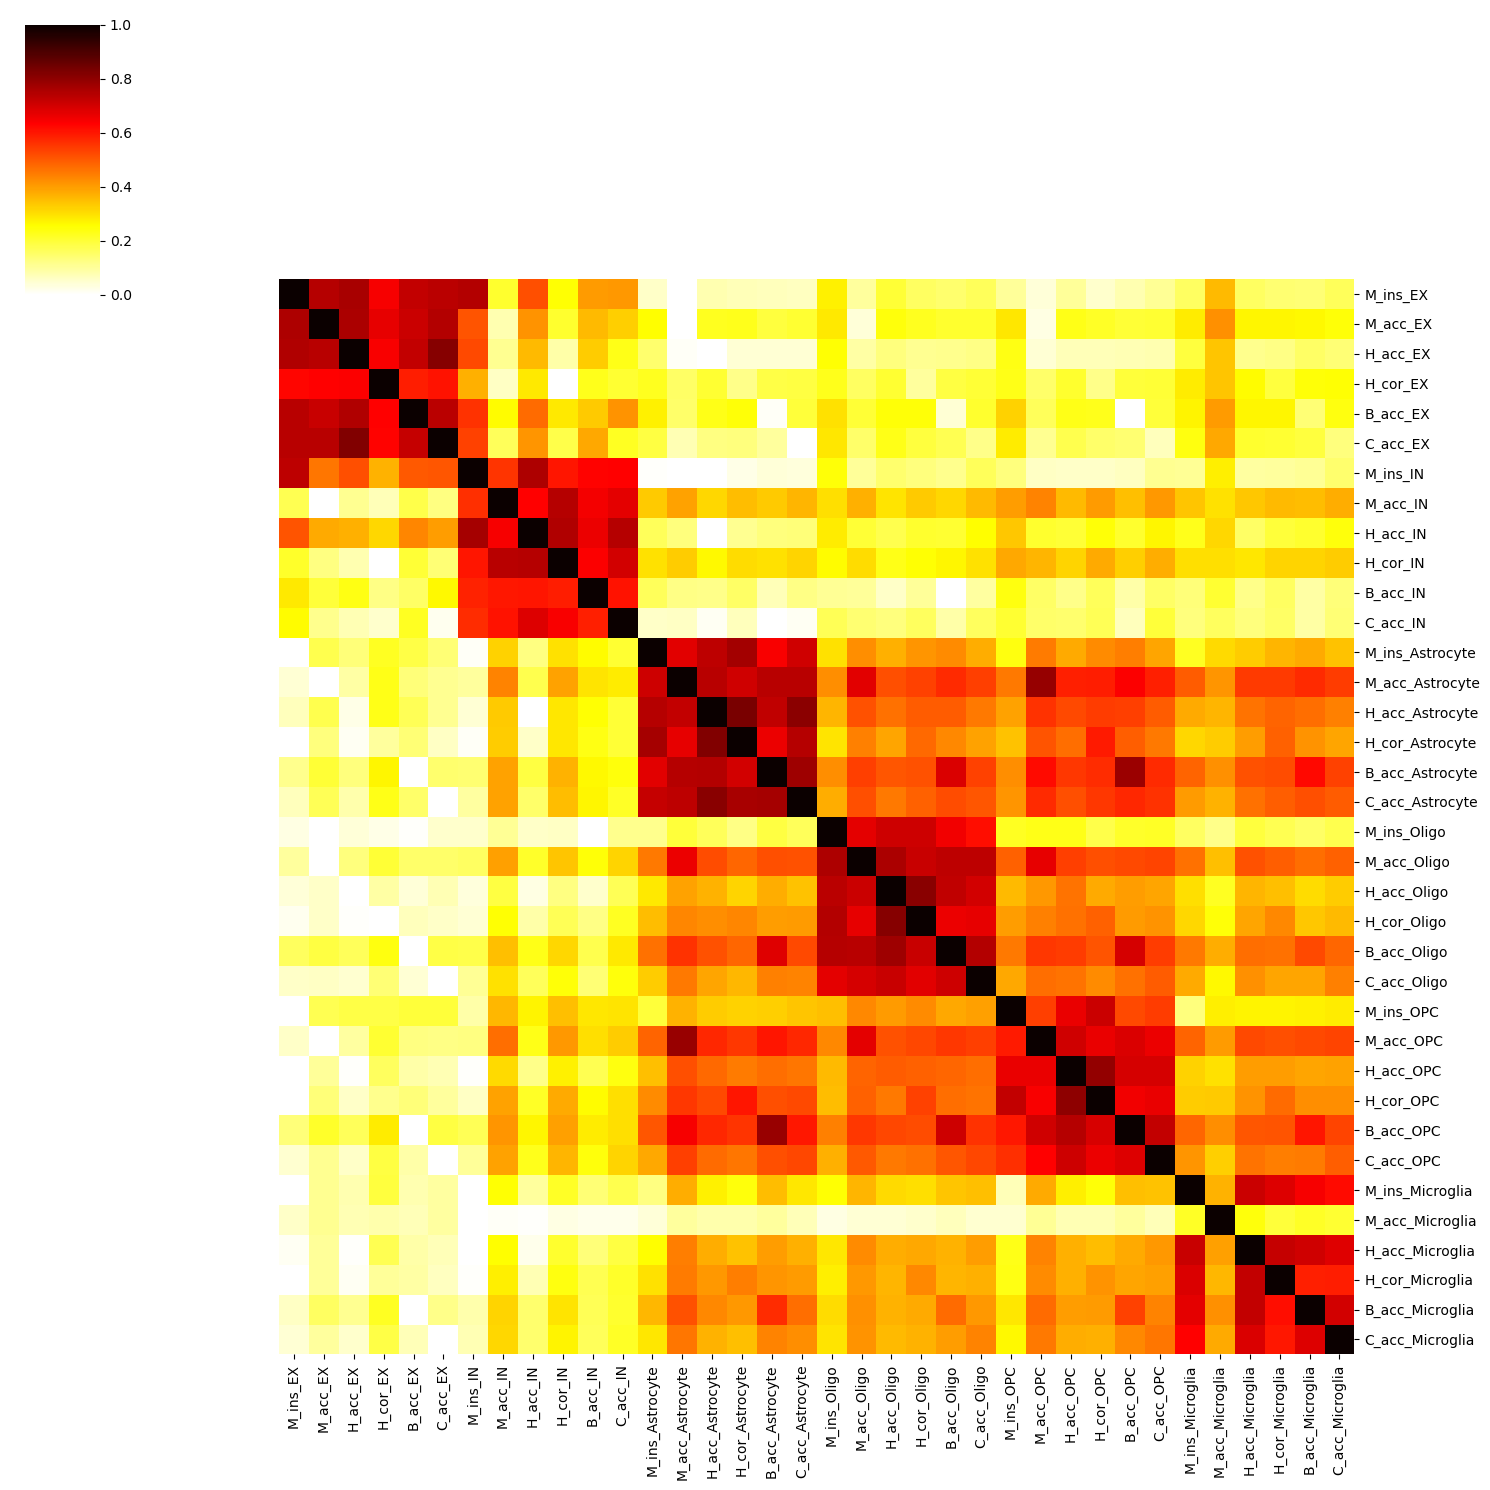

In [12]:
plt.figure(figsize=(20, 20)) 
sns.clustermap(xSpiecesGliaCmp,cmap='hot_r',standard_scale=0,row_cluster=False,col_cluster=False,figsize=(15,15))
# plt.savefig('Figures/cross_region_heatmap.pdf')